# 02 — Paper-Grounded Preprocessing, Weak Labeling, Clustering, and Pseudo Labeling — Revised v5

Fokus penilaian: **Appropriateness of techniques used in pre-processing (20%)**.

Notebook ini membangun dataset modeling dari output Notebook 01 dengan alur:

1. data quality audit,
2. actor-specific feature engineering,
3. literature-derived rule engine,
4. DEA-style input-output efficiency,
5. clustering sebagai support signal,
6. pseudo label untuk target model pada Notebook 03.

> **Important note about label distribution**  
> Pseudo label **tidak dipaksa seimbang**. Jika kelas `Conditional` lebih dominan atau `Not Recommended` lebih sedikit, itu tidak otomatis dianggap masalah. Distribusi label diperlakukan sebagai konsekuensi dari rule domain dan karakteristik dataset. Untuk modeling, ketidakseimbangan kelas ditangani pada Notebook 03 melalui **Stratified K-Fold**, **Macro F1**, **Balanced Accuracy**, dan model dengan `class_weight='balanced'` jika tersedia, bukan dengan mengubah label agar terlihat seimbang.

Target yang dibuat adalah `readiness_label`, yaitu **weak/pseudo label**, bukan ground truth eksternal. Paper dan referensi hanya dipakai untuk mendasari rule dan metodologi; semua nilai numerik tetap dihitung dari dataset beras yang diberikan.

**Revisi v5:** notebook ini menerima output parser v5 dari Notebook 01, menyimpan audit parser jika tersedia, memperjelas justifikasi bobot readiness score, dan menambahkan interpretasi jika silhouette clustering tergolong lemah/moderat.


In [1]:
from pathlib import Path
import json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
PLOT_DIR = OUTPUT_DIR / 'plots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (10, 5.8),
    'figure.dpi': 120,
    'savefig.dpi': 180,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
    'axes.labelsize': 10,
    'axes.titlesize': 14,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'grid.alpha': 0.25,
    'legend.frameon': False,
})

COLORS = {
    'ink':'#1f2937',
    'muted':'#6b7280',
    'good':'#2a9d8f',
    'warn':'#e9c46a',
    'bad':'#e76f51',
    'blue':'#457b9d',
    'purple':'#7b2cbf'
}

LABEL_ORDER = ['Not Recommended', 'Conditional', 'Recommended']
LABEL_COLORS = {'Not Recommended': COLORS['bad'], 'Conditional': COLORS['warn'], 'Recommended': COLORS['good']}

def savefig(name):
    path = PLOT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches='tight')
    print(f'Saved: {path}')
    plt.show()

print('Project root:', PROJECT_ROOT)
print('Output dir:', OUTPUT_DIR)

Project root: c:\Users\USER\Documents\VSCODE\riceguard_notebooks
Output dir: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs


## Methodological grounding: why these rules are defensible

Notebook ini tidak membuat rule secara asal. Setiap komponen pseudo label diturunkan dari pendekatan yang memang umum dipakai dalam domain supply chain, agribisnis, dan weak supervision.

| Komponen | Dasar domain/literatur | Implementasi di notebook | Catatan penggunaan |
|---|---|---|---|
| DEA-style efficiency | Dataset Mendeley ini secara eksplisit disediakan untuk mengembangkan model DEA rantai pasok beras Jawa Barat. DEA juga merupakan metode input-output frontier untuk mengukur efisiensi relatif DMU sejenis. | `dea_score`, dihitung terpisah per aktor. | Farmer dibandingkan dengan farmer, retail dibandingkan dengan retail, dst. Tidak dicampur lintas aktor. |
| R/C viability | Analisis kelayakan finansial usahatani memakai `Revenue Cost Ratio = Total Revenue / Total Cost`; kriteria umum: `R/C > 1` layak, `R/C < 1` tidak layak. | `rc_ratio`, `rc_viability_score`. | Threshold absolut `1` digunakan karena punya makna finansial langsung: output menutup biaya. |
| Margin health | Studi kelayakan finansial juga memakai konsep pendapatan/margin `TR - TC`; margin positif menunjukkan surplus, margin negatif menunjukkan rugi. | `margin`, `margin_ratio`, `margin_score`. | Karena skala uang berbeda antaraktor, ranking margin dilakukan per aktor. |
| Cost and asset performance | SCOR/SCOR-like supply chain performance menilai cost, asset management, reliability/responsiveness/agility. Dataset tidak punya waktu pengiriman atau service level, jadi hanya proxy cost dan asset yang digunakan. | `cost_burden_score`, `asset_utilization_score`. | Tidak mengklaim metrik SCOR lengkap; hanya proxy yang tersedia dari dataset. |
| Crisis stress-test | Dalam supply chain decision support, stress scenario lazim dipakai untuk melihat sensitivitas sistem terhadap shock biaya/output. | `crisis_resilience_score`. | Tidak memakai data perang/eksternal. Skenario hanya memodifikasi variabel internal: biaya naik dan output turun. |
| Weak supervision | Snorkel/weak supervision menggunakan labeling functions atau heuristics untuk membuat label lemah ketika ground truth tidak tersedia. | literature-derived rules + clustering support → `readiness_label`. | Pseudo label dipakai untuk melatih model prediksi, tetapi tidak diklaim sebagai ground truth objektif. |
| Clustering support | Silhouette score digunakan untuk membaca konsistensi cluster ketika ground truth tidak tersedia. | pemilihan `k` dan `cluster_support_score`. | Cluster bukan label utama; cluster hanya support signal yang diberi makna dari rata-rata skor domain. |

### References used for methodological justification

1. Budiman, M. A. (2023). **Rice Supply Chain in West Java Province, Indonesia**. Mendeley Data. DOI: `10.17632/k7c2sgmsj5.1`. Dataset description states that the data are used to develop a DEA model for the rice supply chain in West Java.
2. Charnes, A., Cooper, W. W., & Rhodes, E. (1978). **Measuring the Efficiency of Decision Making Units**. *European Journal of Operational Research*. Foundational CCR DEA model.
3. Banker, R. D., Charnes, A., & Cooper, W. W. (1984). **Some Models for Estimating Technical and Scale Inefficiencies in Data Envelopment Analysis**. *Management Science*. Foundational BCC DEA model.
4. Putra, H. W., Sadeli, A. H., Indrawibawa, D., Hapsari, H., & Djuwendah, E. (2024). **Analisis Komparasi Kelayakan Finansial Usahatani Benih Kentang dengan Sayuran Pakcoy**. *Mimbar Agribisnis*. The paper lists R/C Ratio as a financial feasibility tool with `RC Ratio > 1` feasible and `< 1` not feasible.
5. SCOR / Supply Chain Operations Reference model literature. SCOR defines supply chain processes such as Plan, Source, Make, Deliver, Return/Enable and evaluates performance using attributes such as reliability, responsiveness, agility, cost, and asset management.
6. Ratner, A. et al. (2017). **Snorkel: Rapid Training Data Creation with Weak Supervision**. Weak supervision framework using labeling functions/heuristics when hand labels are unavailable.
7. Rousseeuw, P. J. (1987). **Silhouettes: A Graphical Aid to the Interpretation and Validation of Cluster Analysis**. Silhouette coefficient for cluster validation.


## 1. Load output dari Notebook 01

Notebook ini sengaja membaca `01_consolidated_raw.csv` dan `01_actor_config.json` agar urutan pipeline tetap jelas:

`Notebook 01 → Notebook 02 → Notebook 03`

In [2]:

raw_path = OUTPUT_DIR / '01_consolidated_raw.csv'
config_path = OUTPUT_DIR / '01_actor_config.json'
parser_audit_path = OUTPUT_DIR / '01_parser_audit.csv'

if not raw_path.exists():
    raise FileNotFoundError('outputs/01_consolidated_raw.csv tidak ditemukan. Jalankan Notebook 01 terlebih dahulu.')
if not config_path.exists():
    raise FileNotFoundError('outputs/01_actor_config.json tidak ditemukan. Jalankan Notebook 01 terlebih dahulu.')

df = pd.read_csv(raw_path)
with open(config_path, 'r', encoding='utf-8') as f:
    ACTOR_CONFIG = json.load(f)

print('Raw shape:', df.shape)
print('Actors:', sorted(df['actor'].dropna().unique()))
print('Regions:', sorted(df['region'].dropna().unique()))
print('Actor counts:')
display(df['actor'].value_counts().rename_axis('actor').reset_index(name='n_rows'))
if parser_audit_path.exists():
    print('\nParser audit from Notebook 01:')
    display(pd.read_csv(parser_audit_path))
display(df.head())


Raw shape: (815, 34)
Actors: ['Farmer', 'Middlemen', 'Retail', 'Rice Miller', 'Wholesaler']
Regions: ['Garut', 'Indramayu', 'Karawang', 'Subang', 'Tasikmalaya']
Actor counts:


,actor,n_rows
0,Farmer,400
1,Rice Miller,105
2,Middlemen,104
3,Wholesaler,104
4,Retail,102



Parser audit from Notebook 01:


,sheet,actor,rows_parsed,auto_dmu_assigned,columns
0,Farmer Data,Farmer,400,0,14
1,Rice Miller Data,Rice Miller,105,0,13
2,Middlemen Data,Middlemen,104,0,14
3,Wholesaler Data,Wholesaler,104,28,12
4,Retail Data,Retail,102,0,12


,actor,region,source_row,dmu,land_area,land_lease_value_idr,labor_cost_idr,seed_purchase_value_idr,fertilizer_purchase_value_idr,pesticide_purchase_value_idr,equipment_rent_value_idr,production_value_idr,dmu_original,dmu_auto_assigned,number_of_machines,value_of_milled_grains_idr,amount_of_milled_rice,supporting_equipment_cost_idr,value_of_milled_rice_idr,total_revenue_of_milling_machine_idr,total_rice_purchase_kg,total_rice_purchase_value_idr,building_rent_cost_idr,value_of_rice_sold_idr,total_precipitation,precipitation_quality,value_of_rice_purchase_idr,total_cost,output_value,margin,rc_ratio,margin_ratio,quantity_proxy,cost_per_quantity
0,Farmer,Garut,2,1,"2,800.0000","4,900,000.0000","1,400,000.0000","644,000.0000","3,640,000.0000","364,000.0000","470,000.0000","16,200,000.0000",1.0000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"11,418,000.0000","16,200,000.0000","4,782,000.0000",1.4188,0.4188,"2,800.0000","4,077.8571"
1,Farmer,Garut,3,2,"1,400.0000","4,900,000.0000","500,000.0000","322,000.0000","1,820,000.0000","182,000.0000","540,000.0000","8,100,000.0000",2.0000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"8,264,000.0000","8,100,000.0000","-164,000.0000",0.9802,-0.0198,"1,400.0000","5,902.8571"
2,Farmer,Garut,4,3,"2,000.0000","2,000,000.0000","700,000.0000","200,000.0000","2,600,000.0000","260,000.0000","690,000.0000","14,850,000.0000",3.0000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"6,450,000.0000","14,850,000.0000","8,400,000.0000",2.3023,1.3023,"2,000.0000","3,225.0000"
3,Farmer,Garut,5,4,"1,000.0000","1,800,000.0000","800,000.0000","230,000.0000","1,300,000.0000","100,000.0000","340,000.0000","13,050,000.0000",4.0000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"4,570,000.0000","13,050,000.0000","8,480,000.0000",2.8556,1.8556,"1,000.0000","4,570.0000"
4,Farmer,Garut,6,5,800.0000,"1,520,000.0000","580,000.0000","184,000.0000","1,040,000.0000","104,000.0000","350,000.0000","10,200,000.0000",5.0000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"3,778,000.0000","10,200,000.0000","6,422,000.0000",2.6998,1.6998,800.0000,"4,722.5000"


## 2. Data quality audit dan cleaning dasar

Yang dicek:

- duplikasi `actor-region-dmu`,
- missing value per kolom,
- kolom numerik yang tidak bisa dikonversi,
- nilai negatif pada kolom biaya/output/quantity yang secara domain tidak masuk akal.

Cleaning dibuat konservatif: nilai anomali diubah menjadi `NaN`, lalu ditangani pada tahap feature engineering/imputation, bukan dihapus massal.

In [3]:
protected_cols = {'actor', 'region'}

df_clean = df.copy()
# Standardize text columns
for c in ['actor', 'region']:
    if c in df_clean.columns:
        df_clean[c] = df_clean[c].astype(str).str.strip()

# Numeric conversion except actor/region
conversion_report = []
for col in df_clean.columns:
    if col not in protected_cols:
        before_na = df_clean[col].isna().sum()
        converted = pd.to_numeric(df_clean[col], errors='coerce')
        after_na = converted.isna().sum()
        conversion_report.append({'column': col, 'new_na_after_numeric_conversion': int(after_na - before_na)})
        df_clean[col] = converted

# Basic row validity
before = len(df_clean)
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.dropna(subset=['actor', 'region', 'dmu']).copy()
print(f'Dropped rows without actor/region/dmu: {before - len(df_clean)}')

# Duplicate handling
dup_count = int(df_clean.duplicated(['actor', 'region', 'dmu']).sum())
print('Duplicate actor-region-dmu:', dup_count)
if dup_count:
    df_clean = df_clean.drop_duplicates(['actor', 'region', 'dmu'], keep='first')

# Domain-negative values audit for cost/output/DEA/quantity/asset columns
nonnegative_cols = set()
for cfg in ACTOR_CONFIG.values():
    for key in ['cost_cols', 'output_cols', 'dea_inputs', 'dea_outputs']:
        nonnegative_cols.update(cfg.get(key, []))
    if cfg.get('asset_col'):
        nonnegative_cols.add(cfg['asset_col'])
    if cfg.get('quantity_col'):
        nonnegative_cols.add(cfg['quantity_col'])
nonnegative_cols = [c for c in nonnegative_cols if c in df_clean.columns]

neg_rows = []
for col in nonnegative_cols:
    neg = int((df_clean[col] < 0).sum())
    if neg:
        neg_rows.append({'column': col, 'negative_values_set_to_nan': neg})
        df_clean.loc[df_clean[col] < 0, col] = np.nan

quality_report = pd.DataFrame({
    'column': df_clean.columns,
    'missing_count': [int(df_clean[c].isna().sum()) for c in df_clean.columns],
    'missing_pct': [float(df_clean[c].isna().mean()) for c in df_clean.columns],
    'dtype': [str(df_clean[c].dtype) for c in df_clean.columns],
})

conversion_report = pd.DataFrame(conversion_report)
negative_report = pd.DataFrame(neg_rows) if neg_rows else pd.DataFrame(columns=['column', 'negative_values_set_to_nan'])

print('Clean shape:', df_clean.shape)
print('\nTop missing columns:')
display(quality_report.sort_values('missing_pct', ascending=False).head(15))
print('\nNumeric conversion issues:')
display(conversion_report.query('new_na_after_numeric_conversion > 0').head(15))
print('\nNegative value audit:')
display(negative_report)

quality_report.to_csv(OUTPUT_DIR / '02_data_quality_report.csv', index=False)
conversion_report.to_csv(OUTPUT_DIR / '02_numeric_conversion_report.csv', index=False)
negative_report.to_csv(OUTPUT_DIR / '02_negative_value_report.csv', index=False)

Dropped rows without actor/region/dmu: 0
Duplicate actor-region-dmu: 0
Clean shape: (815, 34)

Top missing columns:


,column,missing_count,missing_pct,dtype
20,total_rice_purchase_kg,711,0.8724,float64
24,total_precipitation,711,0.8724,float64
21,total_rice_purchase_value_idr,711,0.8724,float64
19,total_revenue_of_milling_machine_idr,710,0.8712,float64
18,value_of_milled_rice_idr,710,0.8712,float64
16,amount_of_milled_rice,710,0.8712,float64
15,value_of_milled_grains_idr,710,0.8712,float64
14,number_of_machines,710,0.8712,float64
26,value_of_rice_purchase_idr,609,0.7472,float64
22,building_rent_cost_idr,505,0.6196,float64



Numeric conversion issues:


,column,new_na_after_numeric_conversion



Negative value audit:


,column,negative_values_set_to_nan


## 3. Actor-specific feature engineering

Karena setiap aktor punya struktur bisnis berbeda, fitur dibuat per aktor:

- **Farmer**: biaya input produksi → nilai produksi,
- **Rice Miller**: biaya gabah/mesin/tenaga kerja → nilai beras giling dan revenue penggilingan,
- **Middlemen/Wholesaler/Retail**: biaya pembelian/sewa/tenaga kerja/peralatan → nilai penjualan.

Fitur utama:

- `total_cost`,
- `output_value`,
- `margin`,
- `rc_ratio`,
- `margin_ratio`,
- `asset_utilization`,
- `cost_per_quantity`,
- komposisi biaya.

In [4]:
def safe_sum(frame, cols):
    cols = [c for c in cols if c in frame.columns]
    if not cols:
        return pd.Series(np.nan, index=frame.index)
    return frame[cols].sum(axis=1, skipna=True)

def pct_rank_by_group(series):
    if series.notna().sum() <= 1:
        return pd.Series(0.5, index=series.index)
    return series.rank(pct=True).fillna(0.5)

def add_actor_features(df_in):
    parts = []
    missing_config = []
    for actor, g in df_in.groupby('actor', sort=False):
        if actor not in ACTOR_CONFIG:
            missing_config.append(actor)
            continue
        cfg = ACTOR_CONFIG[actor]
        g = g.copy()
        cost_cols = [c for c in cfg.get('cost_cols', []) if c in g.columns]
        output_cols = [c for c in cfg.get('output_cols', []) if c in g.columns]

        g['total_cost'] = safe_sum(g, cost_cols)
        g['output_value'] = safe_sum(g, output_cols)
        g['margin'] = g['output_value'] - g['total_cost']
        g['rc_ratio'] = g['output_value'] / g['total_cost'].replace(0, np.nan)
        g['margin_ratio'] = g['margin'] / g['total_cost'].replace(0, np.nan)
        g['cost_to_output_ratio'] = g['total_cost'] / g['output_value'].replace(0, np.nan)

        q = cfg.get('quantity_col')
        if q and q in g.columns:
            g['quantity_proxy'] = g[q]
            g['cost_per_quantity'] = g['total_cost'] / g[q].replace(0, np.nan)
            g['output_per_quantity'] = g['output_value'] / g[q].replace(0, np.nan)
        else:
            g['quantity_proxy'] = np.nan
            g['cost_per_quantity'] = np.nan
            g['output_per_quantity'] = np.nan

        a = cfg.get('asset_col')
        if a and a in g.columns:
            g['asset_proxy'] = g[a]
            g['asset_utilization'] = g['output_value'] / g[a].replace(0, np.nan)
        else:
            # For actors without clear asset columns, use output per cost as conservative utilization proxy.
            g['asset_proxy'] = np.nan
            g['asset_utilization'] = g['output_value'] / g['total_cost'].replace(0, np.nan)

        # Cost composition shares. Missing columns are left as NaN to avoid fake zeros.
        share_map = {
            'labor_cost_idr': 'labor_cost_share',
            'building_rent_cost_idr': 'building_rent_share',
            'land_lease_value_idr': 'land_lease_share',
            'supporting_equipment_cost_idr': 'supporting_equipment_share',
            'equipment_rent_value_idr': 'equipment_rent_share',
            'seed_purchase_value_idr': 'seed_cost_share',
            'fertilizer_purchase_value_idr': 'fertilizer_cost_share',
            'pesticide_purchase_value_idr': 'pesticide_cost_share',
            'value_of_rice_purchase_idr': 'rice_purchase_share',
            'value_of_milled_grains_idr': 'milled_grain_purchase_share',
        }
        for src, dst in share_map.items():
            g[dst] = g[src] / g['total_cost'].replace(0, np.nan) if src in g.columns else np.nan

        # Log features for downstream modeling/diagnostics; log1p handles zero safely.
        for col in ['total_cost', 'output_value', 'quantity_proxy', 'asset_proxy']:
            g[f'log_{col}'] = np.log1p(g[col].clip(lower=0))
        g['log_abs_margin'] = np.log1p(g['margin'].abs())
        g['is_margin_negative'] = (g['margin'] < 0).astype(int)
        g['is_rc_below_one'] = (g['rc_ratio'] < 1).astype(int)

        parts.append(g)
    if missing_config:
        print('WARNING: actors without config:', missing_config)
    return pd.concat(parts, ignore_index=True).replace([np.inf, -np.inf], np.nan)

feat = add_actor_features(df_clean)

key_cols = ['actor', 'region', 'dmu', 'total_cost', 'output_value', 'margin', 'rc_ratio', 'margin_ratio', 'asset_utilization', 'cost_per_quantity']
display(feat[[c for c in key_cols if c in feat.columns]].head())

summary_actor = feat.groupby('actor').agg(
    n=('dmu','count'),
    median_rc=('rc_ratio','median'),
    rc_below_1_share=('is_rc_below_one','mean'),
    median_margin=('margin','median'),
    median_total_cost=('total_cost','median'),
    median_output_value=('output_value','median')
).reset_index().sort_values('median_rc')
display(summary_actor)
summary_actor.to_csv(OUTPUT_DIR / '02_actor_feature_summary.csv', index=False)

,actor,region,dmu,total_cost,output_value,margin,rc_ratio,margin_ratio,asset_utilization,cost_per_quantity
0,Farmer,Garut,1,"11,418,000.0000","16,200,000.0000","4,782,000.0000",1.4188,0.4188,"5,785.7143","4,077.8571"
1,Farmer,Garut,2,"8,264,000.0000","8,100,000.0000","-164,000.0000",0.9802,-0.0198,"5,785.7143","5,902.8571"
2,Farmer,Garut,3,"6,450,000.0000","14,850,000.0000","8,400,000.0000",2.3023,1.3023,"7,425.0000","3,225.0000"
3,Farmer,Garut,4,"4,570,000.0000","13,050,000.0000","8,480,000.0000",2.8556,1.8556,"13,050.0000","4,570.0000"
4,Farmer,Garut,5,"3,778,000.0000","10,200,000.0000","6,422,000.0000",2.6998,1.6998,"12,750.0000","4,722.5000"


,actor,n,median_rc,rc_below_1_share,median_margin,median_total_cost,median_output_value
2,Retail,102,0.5069,0.9706,"-2,885,000.0000","5,887,500.0000","3,000,000.0000"
1,Middlemen,104,0.8887,0.6731,"-4,767,673.3991","79,400,000.0000","88,000,000.0000"
4,Wholesaler,104,1.0650,0.4135,"20,000,000.0000","142,800,000.0000","180,000,000.0000"
3,Rice Miller,105,1.0945,0.3238,"8,805,423.5518","126,370,227.9202","139,000,000.0000"
0,Farmer,400,2.1170,0.0950,"10,929,000.0000","9,711,400.0000","24,525,000.0000"


## 4. DEA-style frontier efficiency score

DEA dipakai karena dataset ini bertipe input-output DMU. Untuk menjaga notebook tetap ringan dan mudah direproduksi di lingkungan kompetisi, notebook ini memakai **fast DEA-style frontier approximation**:

1. input dan output diskalakan per aktor,
2. dibuat indeks input dan output,
3. efisiensi relatif dihitung sebagai `output_index / input_index`,
4. skor dinormalisasi terhadap DMU terbaik dalam aktor yang sama sehingga nilai berada pada 0–1.

Pendekatan ini tetap mengikuti logika DEA—membandingkan DMU sejenis berdasarkan input-output—tetapi tidak menjalankan linear programming untuk setiap DMU agar runtime stabil. Dalam laporan, sebutkan sebagai **DEA-style relative efficiency score**, bukan exact CCR/BCC DEA.


In [5]:

def _safe_scale_matrix(M):
    M = np.asarray(M, dtype=float)
    M = np.where(np.isfinite(M), M, np.nan)
    M = np.where(M < 0, np.nan, M)
    med = np.nanmedian(M, axis=0)
    med = np.where((~np.isfinite(med)) | (med <= 0), 1.0, med)
    M = np.where(np.isnan(M), med, M)
    M = np.where(M < 0, 0, M)
    return M / med

def dea_style_frontier_score(group, input_cols, output_cols):
    """Fast input-output frontier approximation.

    Higher output index and lower input index produce higher efficiency.
    Scores are normalized by the best DMU within the same actor, so the
    actor-level frontier receives score 1. This is a DEA-style proxy rather
    than exact CCR/BCC linear-programming DEA.
    """
    if len(group) < 2 or len(input_cols) == 0 or len(output_cols) == 0:
        return np.full(len(group), np.nan)

    X = group[input_cols].apply(pd.to_numeric, errors='coerce').to_numpy(float)
    Y = group[output_cols].apply(pd.to_numeric, errors='coerce').to_numpy(float)
    X = _safe_scale_matrix(X)
    Y = _safe_scale_matrix(Y)

    input_index = np.nanmean(X, axis=1)
    output_index = np.nanmean(Y, axis=1)
    raw_eff = output_index / np.where(input_index <= 0, np.nan, input_index)
    raw_eff = np.where(np.isfinite(raw_eff), raw_eff, np.nan)

    frontier = np.nanmax(raw_eff)
    if not np.isfinite(frontier) or frontier <= 0:
        return np.full(len(group), np.nan)
    return np.clip(raw_eff / frontier, 0, 1)

feat['dea_score'] = np.nan
dea_audit = []
for actor, g in feat.groupby('actor', sort=False):
    cfg = ACTOR_CONFIG.get(actor, {})
    input_cols = [c for c in cfg.get('dea_inputs', []) if c in g.columns]
    output_cols = [c for c in cfg.get('dea_outputs', []) if c in g.columns]
    print(f'DEA-style {actor}: n={len(g)}, inputs={len(input_cols)}, outputs={len(output_cols)}')
    scores = dea_style_frontier_score(g, input_cols, output_cols)
    feat.loc[g.index, 'dea_score'] = scores
    dea_audit.append({
        'actor': actor,
        'n': int(len(g)),
        'input_cols': ', '.join(input_cols),
        'output_cols': ', '.join(output_cols),
        'dea_missing_score': int(pd.isna(scores).sum()),
        'dea_score_median': float(np.nanmedian(scores)) if np.isfinite(np.nanmedian(scores)) else np.nan,
        'dea_method': 'fast DEA-style frontier approximation; not exact CCR/BCC LP DEA'
    })

dea_audit = pd.DataFrame(dea_audit)
display(dea_audit)
display(feat.groupby('actor')['dea_score'].describe())
dea_audit.to_csv(OUTPUT_DIR / '02_dea_audit.csv', index=False)


DEA-style Farmer: n=400, inputs=7, outputs=1
DEA-style Rice Miller: n=105, inputs=4, outputs=2
DEA-style Middlemen: n=104, inputs=5, outputs=1
DEA-style Wholesaler: n=104, inputs=4, outputs=1
DEA-style Retail: n=102, inputs=4, outputs=1


,actor,n,input_cols,output_cols,dea_missing_score,dea_score_median,dea_method
0,Farmer,400,"land_area, land_lease_value_idr, labor_cost_id...",production_value_idr,0,0.2028,fast DEA-style frontier approximation; not exa...
1,Rice Miller,105,"number_of_machines, value_of_milled_grains_idr...","value_of_milled_rice_idr, total_revenue_of_mil...",0,0.2301,fast DEA-style frontier approximation; not exa...
2,Middlemen,104,"total_rice_purchase_kg, total_rice_purchase_va...",value_of_rice_sold_idr,0,0.3249,fast DEA-style frontier approximation; not exa...
3,Wholesaler,104,"value_of_rice_purchase_idr, building_rent_cost...",value_of_rice_sold_idr,0,0.0400,fast DEA-style frontier approximation; not exa...
4,Retail,102,"value_of_rice_purchase_idr, building_rent_cost...",value_of_rice_sold_idr,0,0.5953,fast DEA-style frontier approximation; not exa...


,count,mean,std,min,25%,50%,75%,max
actor,,,,,,,,
Farmer,400.0000,0.2281,0.1060,0.0397,0.1559,0.2028,0.2886,1.0000
Middlemen,104.0000,0.3967,0.2293,0.0578,0.2177,0.3249,0.5688,1.0000
Retail,102.0000,0.6176,0.1303,0.2990,0.5186,0.5953,0.7033,1.0000
Rice Miller,105.0000,0.2971,0.2283,0.0101,0.1192,0.2301,0.4377,1.0000
Wholesaler,104.0000,0.0558,0.0991,0.0028,0.0234,0.0400,0.0655,1.0000


## 5. Literature-derived weak-labeling components

Rule engine dibuat sebagai **skor komponen** agar bisa diaudit. Setiap komponen punya dasar domain dan dihitung hanya dari dataset.

| Komponen | Domain basis | Skor tinggi berarti |
|---|---|---|
| `dea_score_filled` | DEA input-output efficiency | aktor relatif efisien terhadap DMU sejenis |
| `rc_viability_score` | R/C ratio financial viability | nilai output/penjualan cukup menutup biaya |
| `margin_score` | profit/margin health | margin lebih sehat dibanding aktor sejenis |
| `asset_utilization_score` | asset/capacity utilization | output relatif baik terhadap asset/kapasitas |
| `cost_burden_score` | SCOR-like cost performance proxy | biaya tidak terlalu berat dibanding output |
| `crisis_resilience_score` | internal stress-test | tetap viable saat biaya naik atau output turun |

Threshold absolut hanya digunakan untuk konsep yang memang punya makna langsung, yaitu `R/C >= 1`. Threshold lainnya memakai percentile internal dataset agar tidak menambah data eksternal.

> **Kenapa distribusi label tidak harus seimbang?**  
> Pada domain risk/readiness screening, distribusi kelas mengikuti kondisi data dan rule domain. Jika mayoritas DMU masuk `Conditional`, interpretasinya adalah banyak aktor yang masih dapat digunakan tetapi membutuhkan monitoring/intervensi selektif. Notebook ini tidak melakukan oversampling, undersampling, atau penyesuaian threshold hanya untuk membuat kelas lebih rata, karena itu bisa merusak makna domain pseudo label.


In [6]:
# Filled DEA per actor then global fallback
feat['dea_score_filled'] = feat.groupby('actor')['dea_score'].transform(lambda s: s.fillna(s.median()))
feat['dea_score_filled'] = feat['dea_score_filled'].fillna(feat['dea_score'].median()).fillna(0.5).clip(0, 1)

# R/C viability: avoid treating rc=8 as eight times better than rc=1.2.
# rc>=1 is viable; values above 1.25 are capped as fully viable.
feat['rc_viability_score'] = (feat['rc_ratio'] / 1.25).clip(0, 1).fillna(0)

# Margin score and asset/cost percentiles are computed within actor to avoid unfair cross-actor scale comparison.
feat['margin_score'] = feat.groupby('actor')['margin_ratio'].transform(pct_rank_by_group).fillna(0.5)
feat['asset_utilization_score'] = feat.groupby('actor')['asset_utilization'].transform(pct_rank_by_group).fillna(0.5)

# Cost burden: high cost_to_output or cost_per_quantity should reduce score.
# Use cost_to_output as universal proxy; lower burden => higher score.
feat['cost_burden_raw'] = feat['cost_to_output_ratio']
feat['cost_burden_score'] = 1 - feat.groupby('actor')['cost_burden_raw'].transform(pct_rank_by_group)
feat['cost_burden_score'] = feat['cost_burden_score'].fillna(0.5).clip(0, 1)

# Crisis stress-test: count how many internal shock scenarios keep R/C >= 1.
def scenario_rc(row, cost_multiplier=1.0, output_multiplier=1.0):
    cost = row['total_cost'] * cost_multiplier
    output = row['output_value'] * output_multiplier
    if not np.isfinite(cost) or not np.isfinite(output) or cost <= 0:
        return np.nan
    return output / cost

shock_scenarios = []
for s in [0.10, 0.20, 0.30]:
    shock_scenarios.append((f'cost_up_{int(s*100)}', 1+s, 1.0))
    shock_scenarios.append((f'output_down_{int(s*100)}', 1.0, 1-s))
# combined crisis is intentionally included but not over-dominant.
for s in [0.10, 0.20]:
    shock_scenarios.append((f'combined_{int(s*100)}', 1+s, 1-s))

survival_cols = []
for name, cm, om in shock_scenarios:
    col = f'survive_{name}'
    feat[col] = feat.apply(lambda r: 1 if scenario_rc(r, cm, om) >= 1 else 0, axis=1)
    survival_cols.append(col)
feat['crisis_resilience_score'] = feat[survival_cols].mean(axis=1).fillna(0)
feat['crisis_sensitivity_score'] = 1 - feat['crisis_resilience_score']

rule_component_cols = [
    'dea_score_filled', 'rc_viability_score', 'margin_score',
    'asset_utilization_score', 'cost_burden_score', 'crisis_resilience_score'
]

component_summary = feat.groupby('actor')[rule_component_cols].mean().reset_index()
display(component_summary)
component_summary.to_csv(OUTPUT_DIR / '02_rule_component_summary_by_actor.csv', index=False)

,actor,dea_score_filled,rc_viability_score,margin_score,asset_utilization_score,cost_burden_score,crisis_resilience_score
0,Farmer,0.2281,0.9617,0.5012,0.5012,0.4988,0.8337
1,Middlemen,0.3967,0.7107,0.5048,0.5048,0.4952,0.0998
2,Retail,0.6176,0.4385,0.5049,0.5049,0.4951,0.0000
3,Rice Miller,0.2971,0.8440,0.5048,0.5048,0.4952,0.2917
4,Wholesaler,0.0558,0.8180,0.5048,0.5048,0.4952,0.3954


## 6. Cluster-assisted pseudo labeling

Clustering dipakai untuk **membaca struktur alami data**, bukan sebagai ground truth.

Catatan metodologis:

- fitur clustering menggunakan skor terstandardisasi dan log transform, bukan nominal uang mentah saja,
- beberapa nilai `k` dicoba,
- model cluster dipilih berdasarkan silhouette score,
- cluster diberi makna dari rata-rata skor domain, bukan dari nomor cluster.

In [7]:
cluster_features = [
    'dea_score_filled', 'rc_viability_score', 'margin_score', 'asset_utilization_score',
    'cost_burden_score', 'crisis_resilience_score',
    'log_total_cost', 'log_output_value', 'log_abs_margin'
]
cluster_features = [c for c in cluster_features if c in feat.columns]

X_cluster = feat[cluster_features].replace([np.inf, -np.inf], np.nan)
X_cluster = SimpleImputer(strategy='median').fit_transform(X_cluster)
X_cluster = RobustScaler().fit_transform(X_cluster)

# Custom NumPy K-Means is used to avoid occasional environment-specific sklearn KMeans hangs.
def numpy_kmeans(X, k, random_state=42, n_init=5, max_iter=80, tol=1e-5):
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    best_labels, best_centers, best_inertia = None, None, np.inf
    for init in range(n_init):
        # choose actual observations as initial centers
        init_idx = rng.choice(n, size=k, replace=False)
        centers = X[init_idx].copy()
        labels = np.zeros(n, dtype=int)
        for _ in range(max_iter):
            dist = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
            new_labels = dist.argmin(axis=1)
            new_centers = centers.copy()
            for j in range(k):
                mask = new_labels == j
                if mask.any():
                    new_centers[j] = X[mask].mean(axis=0)
                else:
                    new_centers[j] = X[rng.integers(0, n)]
            shift = np.sqrt(((centers - new_centers) ** 2).sum())
            centers = new_centers
            labels = new_labels
            if shift < tol:
                break
        inertia = float(((X - centers[labels]) ** 2).sum())
        if inertia < best_inertia:
            best_labels, best_centers, best_inertia = labels.copy(), centers.copy(), inertia
    return best_labels, best_centers, best_inertia

cluster_rows = []
max_k = min(5, max(2, len(feat) // 100))
for k in range(2, max_k + 1):
    labels, centers, inertia = numpy_kmeans(X_cluster, k, random_state=42 + k, n_init=5)
    if len(np.unique(labels)) < 2:
        continue
    sample_size = min(500, len(X_cluster))
    cluster_rows.append({
        'k': k,
        'silhouette': float(silhouette_score(X_cluster, labels, sample_size=sample_size, random_state=42)),
        'davies_bouldin': float(davies_bouldin_score(X_cluster, labels)),
        'calinski_harabasz': float(calinski_harabasz_score(X_cluster, labels)),
        'inertia': float(inertia),
    })

cluster_selection = pd.DataFrame(cluster_rows).sort_values(['silhouette', 'calinski_harabasz'], ascending=[False, False])
if cluster_selection.empty:
    best_k = 3
else:
    best_k = int(cluster_selection.iloc[0]['k'])

best_labels, best_centers, best_inertia = numpy_kmeans(X_cluster, best_k, random_state=2026, n_init=10)
feat['cluster'] = best_labels

# Cluster support is based on domain score average, not arbitrary cluster id.
cluster_domain_base = feat[rule_component_cols].mean(axis=1)
cluster_mean = cluster_domain_base.groupby(feat['cluster']).mean().sort_values()
if len(cluster_mean) > 1:
    cluster_map = {cl: rank / (len(cluster_mean)-1) for rank, cl in enumerate(cluster_mean.index)}
else:
    cluster_map = {cluster_mean.index[0]: 0.5}
feat['cluster_support_score'] = feat['cluster'].map(cluster_map).astype(float)

cluster_profile = feat.groupby('cluster').agg(
    n=('dmu', 'count'),
    mean_dea=('dea_score_filled', 'mean'),
    mean_rc_score=('rc_viability_score', 'mean'),
    mean_margin_score=('margin_score', 'mean'),
    mean_crisis=('crisis_resilience_score', 'mean'),
    support_score=('cluster_support_score', 'mean'),
    median_rc=('rc_ratio', 'median'),
    median_margin=('margin', 'median')
).sort_values('support_score').reset_index()

print('Selected k:', best_k)
best_silhouette = float(cluster_selection.iloc[0]['silhouette']) if not cluster_selection.empty else np.nan
print('Best silhouette:', round(best_silhouette, 4) if np.isfinite(best_silhouette) else 'n/a')
if np.isfinite(best_silhouette):
    if best_silhouette < 0.25:
        print('Silhouette interpretation: weak cluster separation; clustering should only be used as a minor support signal.')
    elif best_silhouette < 0.50:
        print('Silhouette interpretation: moderate cluster separation; clustering is useful for support, not as the main label source.')
    else:
        print('Silhouette interpretation: clear cluster separation; cluster support is relatively stable.')
display(cluster_selection)
display(cluster_profile)

cluster_selection.to_csv(OUTPUT_DIR / '02_cluster_selection.csv', index=False)
cluster_profile.to_csv(OUTPUT_DIR / '02_cluster_profile.csv', index=False)

Selected k: 3
Best silhouette: 0.2925
Silhouette interpretation: moderate cluster separation; clustering is useful for support, not as the main label source.


,k,silhouette,davies_bouldin,calinski_harabasz,inertia
1,3,0.2925,1.2126,327.6992,"1,850.2167"
2,4,0.2850,1.2015,320.3950,"1,530.1233"
3,5,0.2819,1.2427,305.0120,"1,334.1152"
0,2,0.2653,1.5049,314.9185,"2,410.0577"


,cluster,n,mean_dea,mean_rc_score,mean_margin_score,mean_crisis,support_score,median_rc,median_margin
0,2,381,0.1483,0.8118,0.2924,0.4078,0.0000,1.0405,"820,000.0000"
1,0,109,0.6231,0.4610,0.5157,0.0000,0.5000,0.5124,"-2,855,000.0000"
2,1,325,0.3325,0.9768,0.7458,0.8008,1.0000,2.3719,"35,061,000.0000"


## 7. Final pseudo label fusion

`readiness_score` menggabungkan rule dan cluster support. Bobot dibuat eksplisit agar mudah dipertanggungjawabkan:

- DEA efficiency: 30%
- R/C viability: 20%
- margin health: 15%
- crisis resilience: 15%
- asset utilization: 10%
- cluster support: 10%

**Justifikasi bobot:** bobot ini bukan klaim bobot absolut dari literatur, tetapi prioritas awal untuk decision support. DEA diberi bobot terbesar karena dataset sumber secara eksplisit ditujukan untuk analisis efisiensi input-output dengan DEA. R/C viability dan margin diberi bobot besar karena program bantuan pangan membutuhkan node yang tidak rapuh secara biaya. Crisis resilience ditambahkan karena track berhubungan dengan resource scarcity dan distribusi pada situasi krisis. Asset utilization dipakai sebagai proxy kapasitas, sedangkan cluster support hanya 10% karena clustering digunakan sebagai sinyal pendukung, bukan sumber label utama.

Label akhir:

- `Recommended`: skor ≥ 0.70,
- `Conditional`: 0.40 ≤ skor < 0.70,
- `Not Recommended`: skor < 0.40.

Interpretasi threshold:

- `Recommended` membutuhkan sinyal efisiensi dan viability yang kuat.
- `Conditional` berarti aktor masih dapat dipertimbangkan, tetapi butuh monitoring atau intervensi selektif.
- `Not Recommended` dipakai untuk DMU dengan sinyal readiness paling lemah.

> Threshold **tidak disetel untuk menyeimbangkan kelas**. Kalau hasilnya condong ke `Conditional`, itu dibaca sebagai insight domain: sebagian besar node supply chain belum cukup kuat untuk langsung direkomendasikan, tetapi juga belum cukup buruk untuk dieliminasi.


In [8]:
READINESS_WEIGHTS = {
    'dea_score_filled': 0.30,
    'rc_viability_score': 0.20,
    'margin_score': 0.15,
    'crisis_resilience_score': 0.15,
    'asset_utilization_score': 0.10,
    'cluster_support_score': 0.10,
}

feat['readiness_score'] = 0.0
for col, w in READINESS_WEIGHTS.items():
    feat['readiness_score'] += w * feat[col].fillna(0.5)
feat['readiness_score'] = feat['readiness_score'].clip(0, 1)

feat['readiness_label'] = pd.cut(
    feat['readiness_score'],
    bins=[-np.inf, 0.40, 0.70, np.inf],
    labels=['Not Recommended', 'Conditional', 'Recommended']
).astype(str)

# Rule vote columns for auditability.
feat['vote_ready'] = (
    (feat['dea_score_filled'] >= 0.80).astype(int) +
    (feat['rc_ratio'] >= 1.00).astype(int) +
    (feat['crisis_resilience_score'] >= 0.50).astype(int) +
    (feat['margin_score'] >= 0.60).astype(int)
)
feat['vote_high_risk'] = (
    (feat['dea_score_filled'] < 0.50).astype(int) +
    (feat['rc_ratio'] < 1.00).astype(int) +
    (feat['crisis_resilience_score'] == 0).astype(int) +
    (feat['margin_score'] < 0.30).astype(int)
)

def reason_from_components(row):
    lows = []
    checks = [
        ('low DEA efficiency', row.get('dea_score_filled', np.nan)),
        ('weak R/C viability', row.get('rc_viability_score', np.nan)),
        ('weak margin health', row.get('margin_score', np.nan)),
        ('high crisis sensitivity', row.get('crisis_resilience_score', np.nan)),
        ('weak asset utilization', row.get('asset_utilization_score', np.nan)),
        ('weak cluster support', row.get('cluster_support_score', np.nan)),
    ]
    for name, val in checks:
        if pd.notna(val) and val < 0.40:
            lows.append(name)
    return '; '.join(lows[:3]) if lows else 'balanced domain indicators'

feat['label_reason'] = feat.apply(reason_from_components, axis=1)

label_counts = feat['readiness_label'].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int)
print('Pseudo label distribution (not artificially rebalanced):')
display(label_counts.rename_axis('readiness_label').reset_index(name='count'))
print('Note: class prevalence is treated as a domain-derived result, not a flaw. Notebook 03 handles imbalance with stratified CV, Macro F1, Balanced Accuracy, and class_weight where applicable.')
print('\nActor x label:')
display(pd.crosstab(feat['actor'], feat['readiness_label']).reindex(columns=LABEL_ORDER, fill_value=0))
print('\nRegion x label:')
display(pd.crosstab(feat['region'], feat['readiness_label']).reindex(columns=LABEL_ORDER, fill_value=0))

Pseudo label distribution (not artificially rebalanced):


,readiness_label,count
0,Not Recommended,268
1,Conditional,374
2,Recommended,173


Note: class prevalence is treated as a domain-derived result, not a flaw. Notebook 03 handles imbalance with stratified CV, Macro F1, Balanced Accuracy, and class_weight where applicable.

Actor x label:


readiness_label,Not Recommended,Conditional,Recommended
actor,,,
Farmer,68,220,112
Middlemen,59,24,21
Retail,41,57,4
Rice Miller,48,32,25
Wholesaler,52,41,11



Region x label:


readiness_label,Not Recommended,Conditional,Recommended
region,,,
Garut,79,77,38
Indramayu,32,64,31
Karawang,44,57,10
Subang,29,90,40
Tasikmalaya,84,86,54


## 8. Label audit dan visualisasi

Bagian ini penting untuk menunjukkan bahwa pseudo label tidak dibuat secara tertutup. Kita tampilkan distribusi label, sebaran skor, dan heatmap risiko per aktor-wilayah.

Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\02_paper_grounded_label_distribution.png


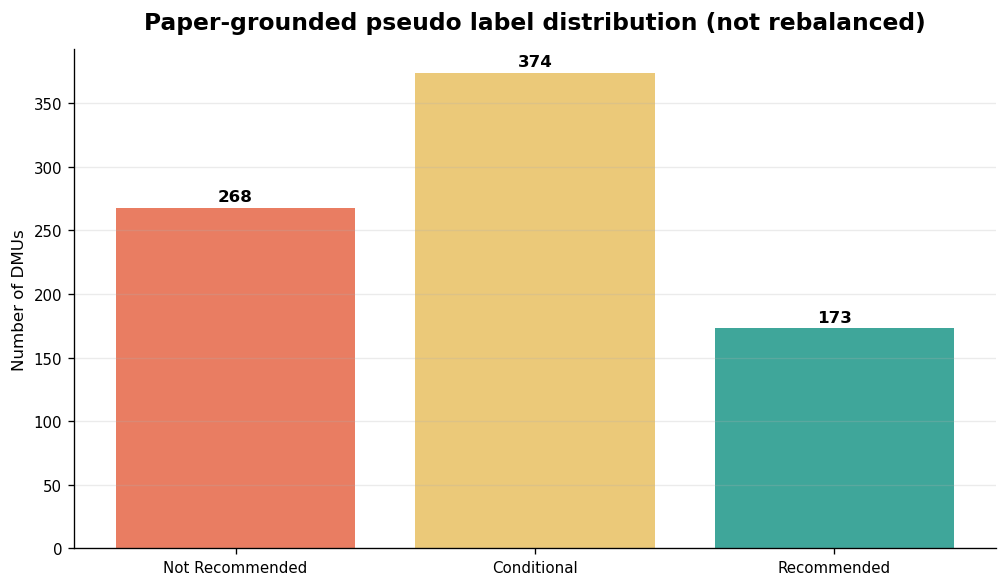

Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\02_paper_grounded_readiness_score_by_actor.png


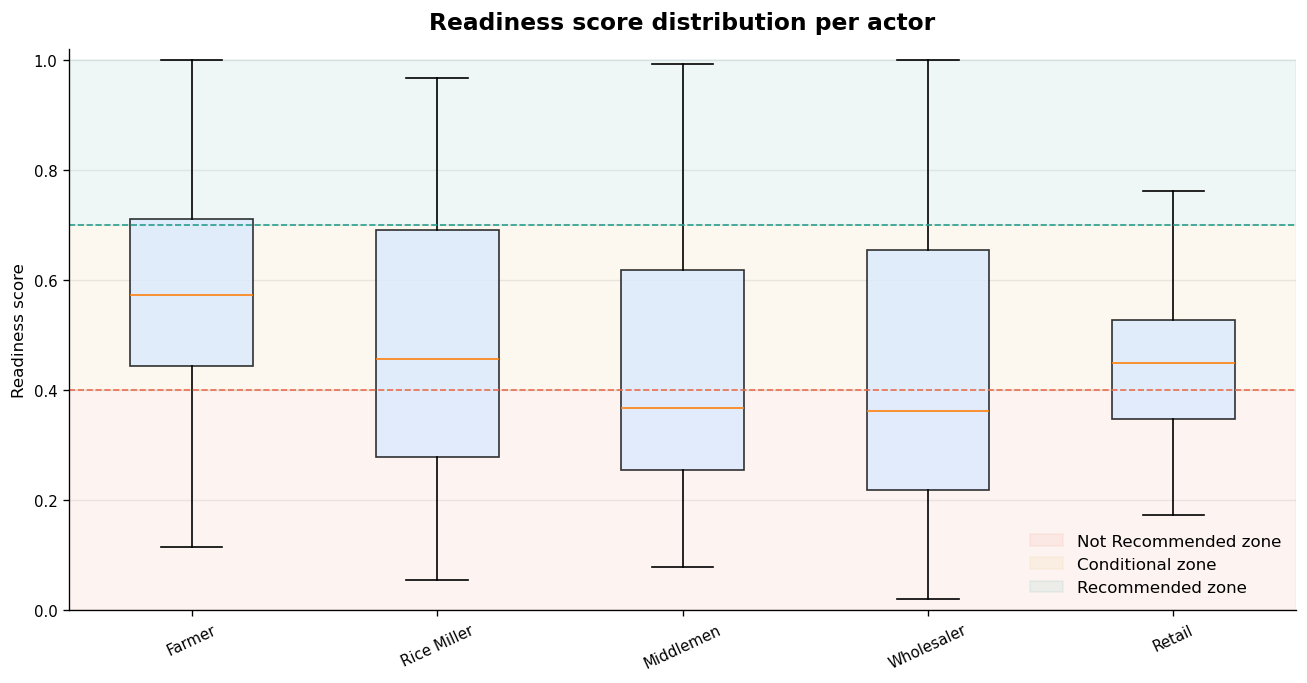

Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\02_improved_actor_region_readiness_heatmap.png


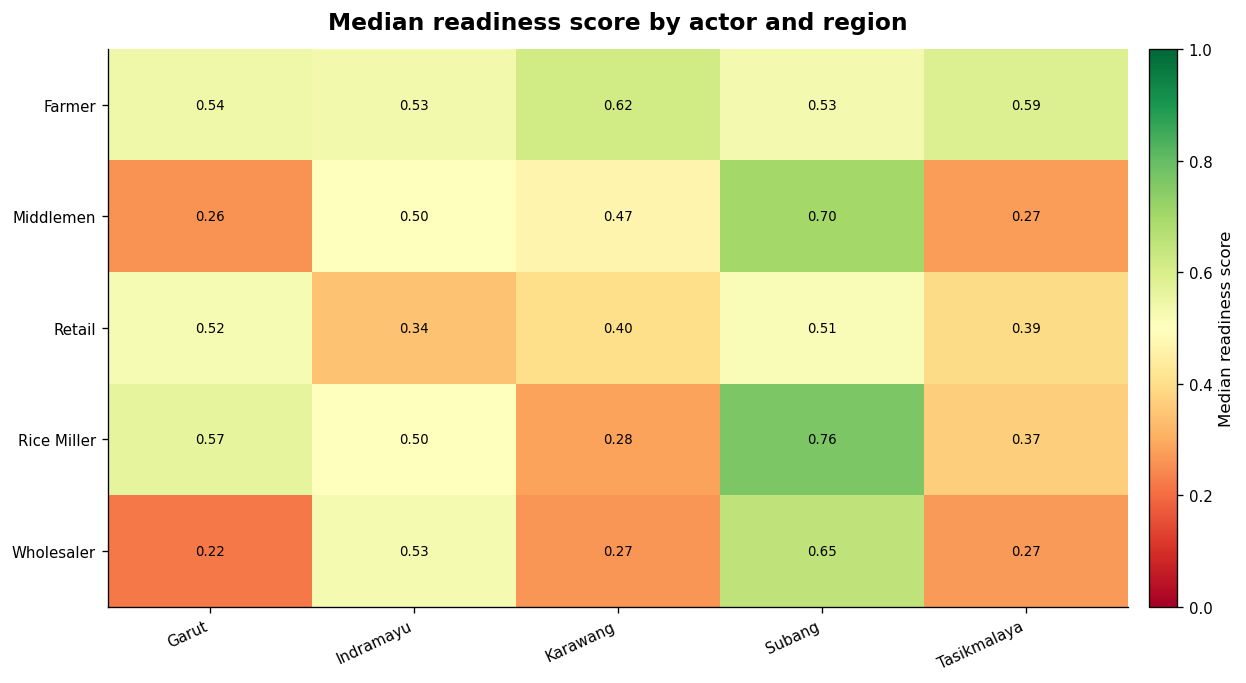

Saved: c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\plots\02_improved_pca_label_projection.png


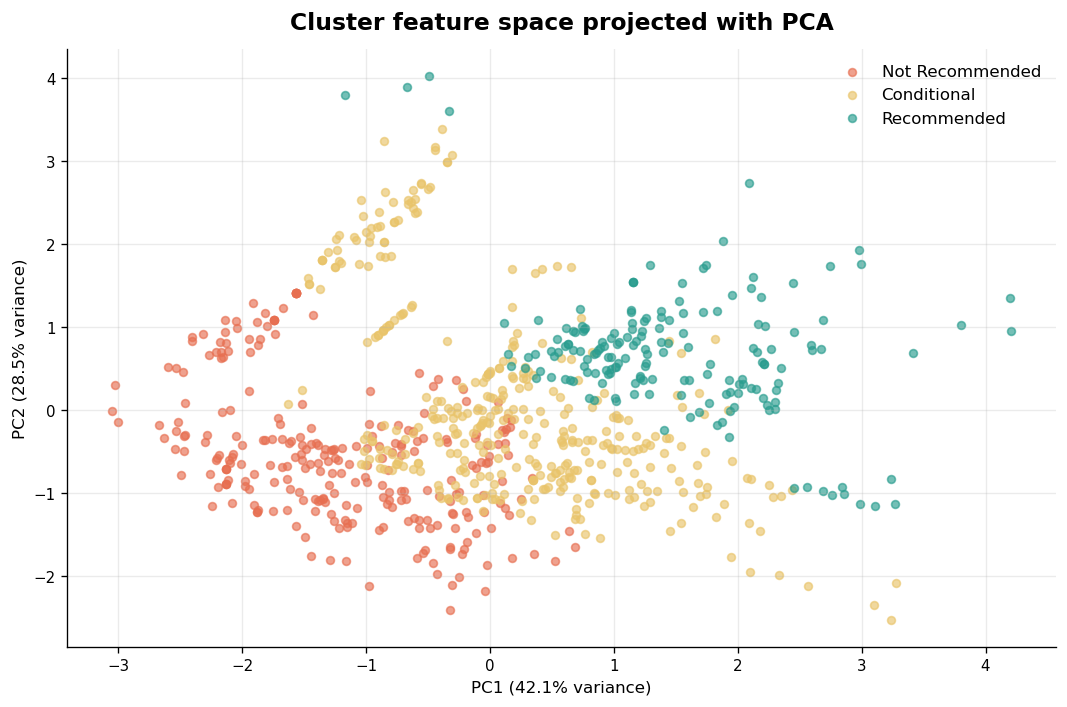

In [9]:
# Label distribution
counts = feat['readiness_label'].value_counts().reindex(LABEL_ORDER).fillna(0)
fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.bar(counts.index, counts.values, color=[LABEL_COLORS[x] for x in counts.index], alpha=0.9)
ax.set_title('Paper-grounded pseudo label distribution (not rebalanced)')
ax.set_ylabel('Number of DMUs')
ax.grid(axis='y')
for b in bars:
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+3, f'{int(b.get_height())}', ha='center', va='bottom', fontsize=10, fontweight='bold')
savefig('02_paper_grounded_label_distribution.png')

# Score distribution by actor with thresholds
actors = feat['actor'].dropna().unique().tolist()
data = [feat.loc[feat['actor'] == a, 'readiness_score'].dropna() for a in actors]
fig, ax = plt.subplots(figsize=(11, 5.8))
box = ax.boxplot(data, labels=actors, showfliers=False, patch_artist=True)
for patch in box['boxes']:
    patch.set_facecolor('#dbeafe')
    patch.set_alpha(0.8)
ax.axhspan(0, 0.40, color=COLORS['bad'], alpha=0.08, label='Not Recommended zone')
ax.axhspan(0.40, 0.70, color=COLORS['warn'], alpha=0.10, label='Conditional zone')
ax.axhspan(0.70, 1.0, color=COLORS['good'], alpha=0.08, label='Recommended zone')
ax.axhline(0.40, color=COLORS['bad'], linestyle='--', linewidth=1)
ax.axhline(0.70, color=COLORS['good'], linestyle='--', linewidth=1)
ax.set_ylim(0, 1.02)
ax.set_ylabel('Readiness score')
ax.set_title('Readiness score distribution per actor')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='y')
ax.legend(loc='lower right')
savefig('02_paper_grounded_readiness_score_by_actor.png')

# Actor-region median score heatmap using matplotlib only
heat = feat.pivot_table(index='actor', columns='region', values='readiness_score', aggfunc='median')
fig, ax = plt.subplots(figsize=(10.5, 5.8))
im = ax.imshow(heat.values, aspect='auto', vmin=0, vmax=1, cmap='RdYlGn')
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=25, ha='right')
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title('Median readiness score by actor and region')
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='Median readiness score')
savefig('02_improved_actor_region_readiness_heatmap.png')

# PCA cluster view
pca = PCA(n_components=2, random_state=42)
xy = pca.fit_transform(X_cluster)
fig, ax = plt.subplots(figsize=(9, 6))
for label in LABEL_ORDER:
    mask = feat['readiness_label'] == label
    ax.scatter(xy[mask,0], xy[mask,1], s=22, alpha=0.65, label=label, color=LABEL_COLORS[label])
ax.set_title('Cluster feature space projected with PCA')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.grid(True)
ax.legend()
savefig('02_improved_pca_label_projection.png')

## 9. Save outputs untuk Notebook 03

Output utama tetap sama agar Notebook 03 tidak perlu diubah:

- `02_modeling_dataset.csv`
- `02_labeling_report.csv`
- `02_cluster_profile.csv`
- `02_preprocessing_metadata.json`

Tambahan output audit disimpan supaya laporan lebih kuat.

In [10]:
# Keep column order readable: metadata + engineered indicators + original columns.
front_cols = [
    'actor', 'region', 'dmu',
    'total_cost', 'output_value', 'margin', 'rc_ratio', 'margin_ratio',
    'quantity_proxy', 'cost_per_quantity', 'output_per_quantity',
    'asset_proxy', 'asset_utilization',
    'dea_score', 'dea_score_filled',
    'rc_viability_score', 'margin_score', 'asset_utilization_score', 'cost_burden_score',
    'crisis_resilience_score', 'crisis_sensitivity_score',
    'cluster', 'cluster_support_score',
    'readiness_score', 'readiness_label', 'vote_ready', 'vote_high_risk', 'label_reason'
]
front_cols = [c for c in front_cols if c in feat.columns]
remaining_cols = [c for c in feat.columns if c not in front_cols]
feat_out = feat[front_cols + remaining_cols].copy()

feat_out.to_csv(OUTPUT_DIR / '02_modeling_dataset.csv', index=False)

label_report = feat_out['readiness_label'].value_counts().reindex(LABEL_ORDER).fillna(0).astype(int).rename_axis('readiness_label').reset_index(name='count')
label_report['share'] = label_report['count'] / label_report['count'].sum()
label_report.to_csv(OUTPUT_DIR / '02_labeling_report.csv', index=False)

actor_region_readiness = feat_out.groupby(['actor', 'region']).agg(
    n=('dmu', 'count'),
    median_readiness_score=('readiness_score', 'median'),
    recommended_share=('readiness_label', lambda s: (s == 'Recommended').mean()),
    not_recommended_share=('readiness_label', lambda s: (s == 'Not Recommended').mean()),
    median_rc=('rc_ratio', 'median'),
    median_dea=('dea_score_filled', 'median'),
    median_crisis=('crisis_resilience_score', 'median'),
).reset_index()
actor_region_readiness.to_csv(OUTPUT_DIR / '02_readiness_by_actor_region.csv', index=False)

rule_audit_cols = ['actor', 'region', 'dmu'] + rule_component_cols + ['cluster_support_score', 'readiness_score', 'readiness_label', 'vote_ready', 'vote_high_risk', 'label_reason']
feat_out[rule_audit_cols].to_csv(OUTPUT_DIR / '02_rule_audit.csv', index=False)

metadata = {
    'notebook': '02_preprocessing_pseudo_labeling_REVISED_v5',
    'n_rows': int(len(feat_out)),
    'n_columns': int(feat_out.shape[1]),
    'selected_cluster_k': int(best_k),
    'best_cluster_silhouette': float(cluster_selection.iloc[0]['silhouette']) if not cluster_selection.empty else None,
    'readiness_weights': READINESS_WEIGHTS,
    'label_thresholds': {
        'Not Recommended': '< 0.40',
        'Conditional': '0.40 <= score < 0.70',
        'Recommended': '>= 0.70'
    },
    'rule_components': rule_component_cols,
    'shock_scenarios': [x[0] for x in shock_scenarios],
    'target_note': 'readiness_label is pseudo label generated by literature-derived rules and internal clustering support, not external ground truth.',
    'class_balance_note': 'Label distribution is not forced to be balanced. Class prevalence follows domain-derived rules and dataset characteristics.',
    'parser_note': 'Compatible with Notebook 01 v5 parser; valid rows with blank raw DMU can be retained using auto-assigned DMU.',
    'cluster_interpretation_note': 'Clustering is used as support signal only. Low/moderate silhouette is reported rather than hidden.',
    'method_references': {
        'dataset': 'Budiman (2023), Rice Supply Chain in West Java Province, Indonesia, Mendeley Data, DOI: 10.17632/k7c2sgmsj5.1',
        'dea_ccr': 'Charnes, Cooper, and Rhodes (1978), Measuring the Efficiency of Decision Making Units',
        'dea_bcc': 'Banker, Charnes, and Cooper (1984), Some Models for Estimating Technical and Scale Inefficiencies in DEA',
        'dea_runtime_note': 'Notebook uses fast DEA-style frontier approximation for reproducibility, not exact LP DEA.',
        'rc_ratio': 'Putra et al. (2024), Mimbar Agribisnis, financial feasibility using R/C ratio > 1',
        'weak_supervision': 'Ratner et al. (2017), Snorkel: Rapid Training Data Creation with Weak Supervision',
        'silhouette': 'Rousseeuw (1987), Silhouettes: A Graphical Aid to the Interpretation and Validation of Cluster Analysis'
    }
}
with open(OUTPUT_DIR / '02_preprocessing_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)



# Save a standalone methodological reference note for report/proposal writing.
reference_note = '''# Notebook 02 Methodological Notes

- Pseudo labels are not external ground truth; they are generated using weak supervision.
- Class distribution is not forced to be balanced. The prevalence of Conditional/Recommended/Not Recommended follows the domain rules and dataset characteristics.
- R/C viability uses the financial feasibility threshold R/C >= 1.
- DEA-style score is used because the source dataset is designed for DEA-based rice supply chain efficiency analysis. For runtime stability, this notebook uses a fast frontier approximation rather than exact LP DEA.
- SCOR-like cost/asset proxy is used only where the dataset provides cost/output/asset variables. Responsiveness or reliability are not claimed because time/service data are unavailable.
- Crisis stress-test uses only internal variables by simulating cost increase and output decrease. No external war, MBG, road, population, or price data are used.
- The readiness score weights are an initial decision-support design choice; they are transparent and can be tuned by stakeholders. They are not tuned to force class balance.
- Clustering is treated as a support signal only. If silhouette is low/moderate, that is reported transparently and does not invalidate the rule-based label.
'''
with open(OUTPUT_DIR / '02_methodological_notes.md', 'w', encoding='utf-8') as f:
    f.write(reference_note)

print('Saved Notebook 02 outputs:')
for p in sorted(OUTPUT_DIR.glob('02_*')):
    print('-', p)

Saved Notebook 02 outputs:
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\02_actor_feature_summary.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\02_cluster_profile.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\02_cluster_selection.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\02_data_quality_report.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\02_dea_audit.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\02_labeling_report.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\02_methodological_notes.md
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\02_modeling_dataset.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\02_negative_value_report.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\02_numeric_conversion_report.csv
- c:\Users\USER\Documents\VSCODE\riceguard_notebooks\outputs\02_preprocessing_metadata.json
- c:\Users\USE

## 10. Quick interpretation for report

Gunakan poin berikut untuk narasi laporan:

1. Dataset tidak memiliki label ground truth, sehingga digunakan **weak supervision**.
2. Rule dibuat dari paper/domain basis: DEA input-output efficiency, R/C financial viability, SCOR-like cost/asset proxy, dan stress-test internal.
3. Clustering hanya menjadi **support signal**, bukan sumber label tunggal.
4. Distribusi pseudo label **tidak dipaksa seimbang**. Jika kelas `Conditional` dominan, itu berarti banyak DMU berada di zona abu-abu: belum kuat untuk direkomendasikan penuh, tetapi belum cukup lemah untuk dieliminasi.
5. Model pada Notebook 03 mempelajari pola pseudo label ini untuk memprediksi kelas kesiapan/risk actor supply chain. Evaluasi menggunakan Macro F1 dan Balanced Accuracy agar tetap adil terhadap kelas yang lebih kecil.


In [11]:
print('Final pseudo label summary:')
display(label_report)

print('\nTop 10 actor-region groups by median readiness score:')
display(actor_region_readiness.sort_values('median_readiness_score', ascending=False).head(10))

print('\nBottom 10 actor-region groups by median readiness score:')
display(actor_region_readiness.sort_values('median_readiness_score', ascending=True).head(10))

print('\nInterpretation reminder:')
print('- Recommended: strong relative efficiency/viability/resilience signal.')
print('- Conditional: usable with monitoring or selective intervention.')
print('- Not Recommended: weak readiness signal; needs intervention before being used as a primary supply node.')

Final pseudo label summary:


,readiness_label,count,share
0,Not Recommended,268,0.3288
1,Conditional,374,0.4589
2,Recommended,173,0.2123



Top 10 actor-region groups by median readiness score:


,actor,region,n,median_readiness_score,recommended_share,not_recommended_share,median_rc,median_dea,median_crisis
18,Rice Miller,Subang,21,0.7623,0.6190,0.1905,1.3288,0.5056,0.7500
8,Middlemen,Subang,21,0.7005,0.5238,0.2857,1.0841,0.5990,0.0000
23,Wholesaler,Subang,21,0.6503,0.0476,0.1429,1.6056,0.0514,1.0000
2,Farmer,Karawang,53,0.6154,0.1321,0.1132,2.0732,0.2066,1.0000
4,Farmer,Tasikmalaya,110,0.5877,0.4091,0.1273,2.3789,0.1976,1.0000
15,Rice Miller,Garut,24,0.5651,0.2500,0.4583,1.2001,0.2412,0.3750
0,Farmer,Garut,98,0.5417,0.3061,0.2857,2.3967,0.2150,1.0000
1,Farmer,Indramayu,62,0.5325,0.2742,0.1452,1.7726,0.2091,1.0000
3,Farmer,Subang,77,0.5288,0.1688,0.1429,1.9662,0.2016,1.0000
21,Wholesaler,Indramayu,16,0.5258,0.1875,0.0625,1.2090,0.0739,0.3750



Bottom 10 actor-region groups by median readiness score:


,actor,region,n,median_readiness_score,recommended_share,not_recommended_share,median_rc,median_dea,median_crisis
20,Wholesaler,Garut,25,0.2194,0.0000,0.8000,0.9263,0.0220,0.0000
5,Middlemen,Garut,24,0.2584,0.0000,0.7500,0.7365,0.2390,0.0000
22,Wholesaler,Karawang,14,0.2655,0.0714,0.7857,0.9823,0.0423,0.0000
24,Wholesaler,Tasikmalaya,28,0.2725,0.2143,0.6071,0.9983,0.0410,0.0000
9,Middlemen,Tasikmalaya,29,0.2743,0.0345,0.7241,0.7716,0.2513,0.0000
17,Rice Miller,Karawang,14,0.2813,0.0000,0.8571,0.9396,0.1590,0.0000
11,Retail,Indramayu,16,0.3425,0.0000,0.6875,0.4729,0.5325,0.0000
19,Rice Miller,Tasikmalaya,29,0.3670,0.0690,0.5862,1.0760,0.1675,0.0000
14,Retail,Tasikmalaya,28,0.3943,0.0000,0.5357,0.4956,0.5484,0.0000
12,Retail,Karawang,16,0.4020,0.0000,0.5000,0.4942,0.5829,0.0000



Interpretation reminder:
- Recommended: strong relative efficiency/viability/resilience signal.
- Conditional: usable with monitoring or selective intervention.
- Not Recommended: weak readiness signal; needs intervention before being used as a primary supply node.
